Data loading + Preprocessing data

In [ ]:
import pickle
import pandas as pd

with open('/content/sample_data/A2Q1_data.pkl', 'rb') as file:
    data1 = pickle.load(file)


{'X_train':      Final_Alginate_Conc_(%w/v)  Final_Gelatin_Conc_(%w/v)  \
605                     0.40625                       0.20   
612                     0.46875                       0.20   
310                     0.00000                       0.00   
340                     0.50000                       0.00   
84                      0.12500                       0.00   
..                          ...                        ...   
9                       0.37500                       0.10   
256                     0.37500                       0.15   
442                     0.37500                       0.00   
183                     0.25000                       0.50   
209                     0.00000                       0.00   

     Final_GelMA_Conc_(%w/v)  Final_Hyaluronic_Acid_Conc_(%w/v)  \
605                 0.000000                                0.0   
612                 0.000000                                0.0   
310                 0.000000              

In [ ]:
with open('/content/sample_data/A2Q1_data_regression.pkl', 'rb') as file:
    data2 = pickle.load(file)

df = pd.read_pickle('/content/sample_data/A2Q1_data_regression.pkl')
print(data2)

{'X_train':      Final_Alginate_Conc_(%w/v)  Final_Gelatin_Conc_(%w/v)  \
605                     0.40625                       0.20   
612                     0.46875                       0.20   
310                     0.00000                       0.00   
340                     0.50000                       0.00   
84                      0.12500                       0.00   
..                          ...                        ...   
9                       0.37500                       0.10   
256                     0.37500                       0.15   
442                     0.37500                       0.00   
183                     0.25000                       0.50   
209                     0.00000                       0.00   

     Final_GelMA_Conc_(%w/v)  Final_Hyaluronic_Acid_Conc_(%w/v)  \
605                 0.000000                                0.0   
612                 0.000000                                0.0   
310                 0.000000              

In [ ]:
import torch

# CUDA support
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f"Device is {device}")

Device is cpu


Initial Configuration

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

X_test = df['X_test']
y_test = df['y_test']

X_train = df['X_train']
y_train = df['y_train']

Xm, XM = X_train.min(), X_train.max()
ym, yM = y_train.min(), y_train.max()

Default models

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import OrderedDict
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader, TensorDataset, Subset
import numpy as np

class DefaultDNN(nn.Module):
    def __init__(self, layers, min_val, max_val):
        super(DefaultDNN, self).__init__()
        self.depth = len(layers) - 1

        self.min_val = torch.tensor([min_val]).float().to(device)
        self.max_val = torch.tensor([max_val]).float().to(device)
        self.activation = nn.Tanh

        layer_list = list()
        for i in range(self.depth - 1):
            layer_list.append(('layer_%d' % i, nn.Linear(layers[i], layers[i+1])))
            layer_list.append(('activation_%d' % i, self.activation()))

        layer_list.append(('layer_%d' % (self.depth - 1), nn.Linear(layers[-2], layers[-1])))
        self.layers = nn.Sequential(OrderedDict(layer_list))

    def forward(self, x):
        res = (x - self.min_val) / (self.max_val - self.min_val)
        return self.layers(res)

def train_default_model(X_train, y_train, layers, is_regression=True):
  kf = KFold(n_splits=5, shuffle=True, random_state=42)
  dataset = TensorDataset(X_train, y_train)
  cv_scores = []

  for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
      train_loader = DataLoader(Subset(dataset, train_idx), batch_size=32, shuffle=True)
      val_loader = DataLoader(Subset(dataset, val_idx), batch_size=32)

      model = DefaultDNN(layers, X_train.min(), X_train.max()).to(device)

      optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
      criterion = nn.MSELoss() if is_regression else nn.BCEWithLogitsLoss()

      for epoch in range(20):
        model.train()
        for batch_X, batch_y in train_loader:
          optimizer.zero_grad()
          loss = criterion(model(batch_X), batch_y)
          loss.backward()
          optimizer.step()

      model.eval()
      fold_loss = 0
      with torch.no_grad():
        for vX, vy in val_loader:
              fold_loss += criterion(model(vX), vy).item()
        cv_scores.append(fold_loss / len(val_loader))
        print(f"Fold {fold+1} Loss: {cv_scores[-1]:.4f}")

  full_train_loader = DataLoader(dataset, batch_size=32, shuffle=True)
  final_model = DefaultDNN(layers, X_train.min(), X_train.max()).to(device)
  optimizer = optim.SGD(final_model.parameters(), lr=0.001, momentum=0.9)
  criterion = nn.MSELoss() if is_regression else nn.BCEWithLogitsLoss()

  for epoch in range(50):
    final_model.train()
    for batch_X, batch_y in full_train_loader:
      optimizer.zero_grad()
      loss = criterion(final_model(batch_X), batch_y)
      loss.backward()
      optimizer.step()

  return final_model, np.mean(cv_scores)


Activation functions

In [ ]:
class ActivationDNN(nn.Module):
    def __init__(self, layers, min_val, max_val, act_type='relu'):
        super(ActivationDNN, self).__init__()
        self.depth = len(layers) - 1

        self.min_val = torch.as_tensor(min_val, dtype=torch.float32, device=device)
        self.max_val = torch.as_tensor(max_val, dtype=torch.float32, device=device)

        layer_list = []
        for i in range(self.depth - 1):
            layer_list.append(('layer_%d' % i, nn.Linear(layers[i], layers[i+1])))

            if act_type == 'relu':
                layer_list.append(('act_%d' % i, nn.ReLU()))
            elif act_type == 'tanh':
                layer_list.append(('act_%d' % i, nn.Tanh()))
            elif act_type == 'mixed':
                act = nn.ReLU() if i == 0 else nn.Tanh()
                layer_list.append(('act_%d' % i, act))

        layer_list.append(('layer_%d' % (self.depth - 1), nn.Linear(layers[-2], layers[-1])))
        self.layers = nn.Sequential(OrderedDict(layer_list))

    def forward(self, x):
        # Corrected: Referencing self.min_val and self.max_val
        res = (x - self.min_val) / (self.max_val - self.min_val + 1e-8)
        return self.layers(res)

def test_activations(X_train, y_train, layers):
    act_types = ['relu', 'tanh', 'mixed']
    results = {}

    for act in act_types:
        print(f"\n--- Testing Activation: {act} ---")

        # Use our previous 5-fold CV logic
        kf = KFold(n_splits=5, shuffle=True, random_state=42)
        dataset = TensorDataset(X_train, y_train)
        fold_losses = []

        for train_idx, val_idx in kf.split(X_train):
            train_loader = DataLoader(Subset(dataset, train_idx), batch_size=32, shuffle=True)
            val_loader = DataLoader(Subset(dataset, val_idx), batch_size=32)

            model = ActivationDNN(layers, X_train.min(), X_train.max(), act_type=act).to(device)
            optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
            criterion = nn.BCEWithLogitsLoss() # For Classification

            # Short training for comparison
            for epoch in range(20):
                model.train()
                for bx, by in train_loader:
                    optimizer.zero_grad(); criterion(model(bx), by).backward(); optimizer.step()

            model.eval()
            with torch.no_grad():
                v_loss = sum(criterion(model(vx), vy).item() for vx, vy in val_loader) / len(val_loader)
                fold_losses.append(v_loss)

        avg_loss = np.mean(fold_losses)
        results[act] = avg_loss
        print(f"Average CV Loss for {act}: {avg_loss:.6f}")

    # Determine the winner
    best_act = min(results, key=results.get)
    print(f"\n BEST PERFORMER: {best_act.upper()}")
    return best_act, results

Learning rate and momentum

y min/max: 0.0 1.0
Training: LR=1e-2, Mom=0.9
Training: LR=1e-2, Mom=0.0
Training: LR=1e-4, Mom=0.9
Training: LR=1e-4, Mom=0.0
Training: Default (1e-3, 0.9)


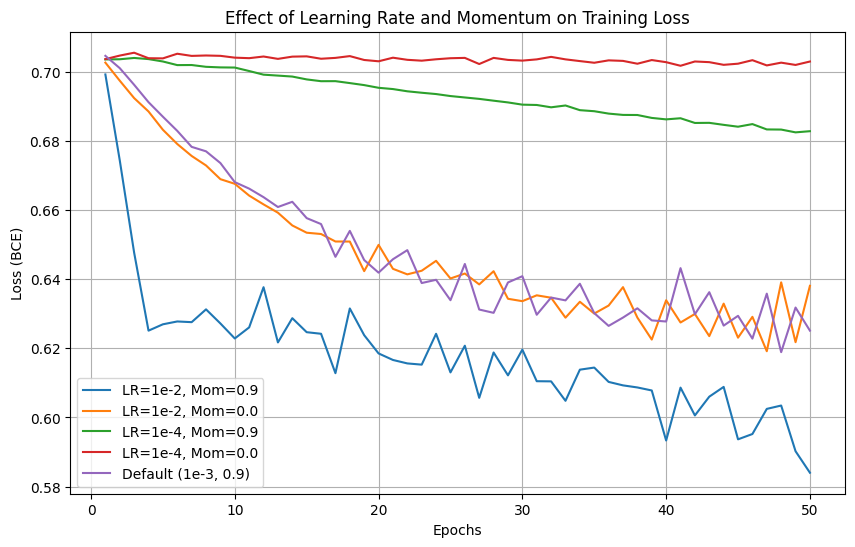

In [ ]:
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
import copy

configs = [
    {'lr': 0.01,   'momentum': 0.9, 'label': 'LR=1e-2, Mom=0.9'},
    {'lr': 0.01,   'momentum': 0.0, 'label': 'LR=1e-2, Mom=0.0'},
    {'lr': 0.0001, 'momentum': 0.9, 'label': 'LR=1e-4, Mom=0.9'},
    {'lr': 0.0001, 'momentum': 0.0, 'label': 'LR=1e-4, Mom=0.0'},
    {'lr': 0.001,  'momentum': 0.9, 'label': 'Default (1e-3, 0.9)'}
]


def get_loss_curve(X, y, layers, lr, momentum, base_state, epochs=50, batch_size=32):
  min_val = X.min(dim=0).values
  max_val = X.max(dim=0).values

  model = ActivationDNN(layers, min_val, max_val, act_type='relu').to(device)
  model.load_state_dict(copy.deepcopy(base_state))

  optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)
  criterion = torch.nn.BCEWithLogitsLoss()

  loader = DataLoader(TensorDataset(X, y), batch_size=batch_size, shuffle=True)
  loss_history = []

  for epoch in range(epochs):
    model.train()
    total_loss = 0

    for bx, by in loader:
      optimizer.zero_grad()
      logits = model(bx)
      loss = criterion(logits, by)
      loss.backward()
      optimizer.step()
      total_loss += loss.item()

    loss_history.append(total_loss / len(loader))
  return loss_history
plt.figure(figsize=(10, 6))

X_train = X_train.astype(np.float32)
y_train = y_train.replace({'Y': 1, 'N': 0}).astype(np.float32)

X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32, device=device)
y_train_bin = (y_train >= 70).astype(np.float32)
y_train_tensor = torch.tensor(y_train_bin.values, dtype=torch.float32, device=device).view(-1, 1)
print("y min/max:", y_train_tensor.min().item(), y_train_tensor.max().item())

input_dim = X_train_tensor.shape[1]
layers = [input_dim, 64, 32, 1]

min_val = X_train_tensor.min(dim=0).values
max_val = X_train_tensor.max(dim=0).values
base_model = ActivationDNN(layers, min_val, max_val, act_type='relu').to(device)
base_state = base_model.state_dict()

for cfg in configs:
    print(f"Training: {cfg['label']}")
    losses = get_loss_curve(
        X_train_tensor, y_train_tensor, layers,
        lr=cfg['lr'], momentum=cfg['momentum'],
        base_state=base_state,
        epochs=50, batch_size=32
    )
    losses = [float(x) for x in losses]
    plt.plot(range(1, len(losses) + 1), losses, label=cfg['label'])

plt.title("Effect of Learning Rate and Momentum on Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (BCE)")
plt.legend()
plt.grid(True)
plt.show()

Best model vs default

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

def train_full_model(X_train, y_train, layers, lr, momentum, act_type='relu', epochs=100):

  min_val = X_train.min(dim=0).values
  max_val = X_train.max(dim=0).values

  model = ActivationDNN(layers, min_val, max_val, act_type=act_type).to(device)

  optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)
  criterion = torch.nn.BCEWithLogitsLoss()

  loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)

  for epoch in range(epochs):
    model.train()
    for bx, by in loader:
      optimizer.zero_grad()
      logits = model(bx)
      loss = criterion(logits, by)
      loss.backward()
      optimizer.step()

  return model

def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        logits = model(X_test)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()

    y_true = y_test.cpu().numpy()
    y_pred = preds.cpu().numpy()

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)

    return acc, prec, rec


default_model = train_full_model(
    X_train_tensor, y_train_tensor,
    layers,
    lr=1e-3,
    momentum=0.9,
    act_type='tanh'
)


best_model = train_full_model(
    X_train_tensor, y_train_tensor,
    layers,
    lr=1e-2,
    momentum=0.9,
    act_type='relu'
)

X_test = X_test.to_numpy(dtype=np.float32)
y_test = y_test.to_numpy(dtype=np.float32)

y_test_bin = (y_test >= 70).astype(np.float32)

X_test_tensor = torch.tensor(
    X_test, dtype=torch.float32, device=device
)

y_test_tensor = torch.tensor(
    y_test_bin, dtype=torch.float32, device=device
).view(-1, 1)

default_metrics = evaluate_model(default_model, X_test_tensor, y_test_tensor)
best_metrics = evaluate_model(best_model, X_test_tensor, y_test_tensor)

print("Default Model (Acc, Prec, Rec):", default_metrics)
print("Best Model (Acc, Prec, Rec):", best_metrics)

Default Model (Acc, Prec, Rec): (0.6666666666666666, 0.6666666666666666, 1.0)
Best Model (Acc, Prec, Rec): (0.6111111111111112, 0.6595744680851063, 0.8611111111111112)


**Question 2**: **PINNS for Damped Oscillators**

Data generation

t: [ 0.   0.5  1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5
  7.   7.5  8.   8.5  9.   9.5 10. ]
x: [ 1.          0.88155612  0.5688847   0.15345543 -0.25843308 -0.57049451
 -0.72012509 -0.68736321 -0.49773714 -0.21014254  0.09903602  0.35562186
  0.50491198  0.52238818  0.41630982  0.22334433 -0.00321505 -0.20758623
 -0.34384765 -0.38718807 -0.33604881]
v: [ 0.         -0.45627933 -0.76290843 -0.86240773 -0.75147531 -0.47591631
 -0.11560735  0.23706156  0.50107714  0.62291311  0.58823421  0.41956304
  0.16933301 -0.09668365 -0.31463006 -0.4386611  -0.44842653 -0.35295428
 -0.18414865  0.01139525  0.1855992 ]


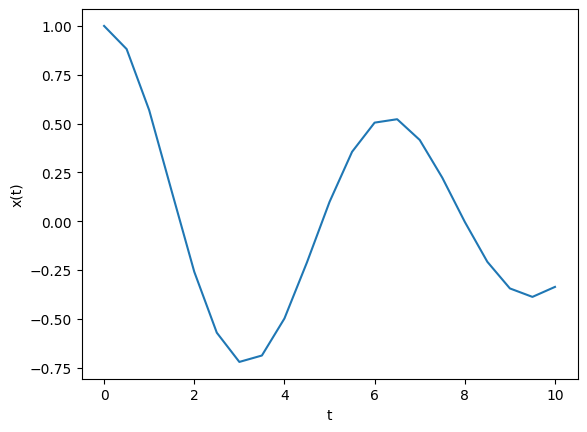

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

gamma = 0.1
omega = 1

x0 = 1
v0 = 0

def damped_oscillator(t, y):
    x, v = y
    dxdt = v
    dvdt = -2*gamma*v - (omega**2)*x
    return [dxdt, dvdt]

step_size = 0.5
t_eval = np.arange(0, 10 + 1e-12, step_size)

t_span = [0, 10]
y0 = [x0, v0]

sol = solve_ivp(damped_oscillator, t_span, y0, t_eval=t_eval)

t = sol.t
x = sol.y[0]
v = sol.y[1]

print("t:", t)
print("x:", x)
print("v:", v)

plt.plot(sol.t, sol.y[0])
plt.xlabel("t")
plt.ylabel("x(t)")
plt.show()

PINN setup

In [ ]:
from scipy.integrate import odeint
from scipy.optimize import minimize
import torch
import torch.nn as nn
from collections import OrderedDict

max_t = 10
step_size = 0.5

p_ = (0.3, 1.2)

ic = 1

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

gamma_data = 0.1
omega_data = 1

x0 = 1
v0 = 0

def damped_oscillator(t, y):
    x, v = y
    dxdt = v
    dvdt = -2*gamma_data*v - (omega_data**2)*x
    return [dxdt, dvdt]

X = x.reshape(-1, 1)

noise = 0.03

xbar = np.mean(X, axis=0)
Xn = X + noise * xbar * np.random.randn(*X.shape)

y_train = Xn.copy()

t_train = t.reshape(-1, 1)
X = x.reshape(-1, 1)
t_test = np.arange(np.min(t_train),np.max(t_train)+(t_train[1]-t_train[0])/2,(t_train[1]-t_train[0])/2)
t_colloc = np.linspace(0, 10, 1000).reshape(-1, 1)

plt.grid()
plt.title("Trajectories")
plt.plot(t_train, y_train[:, 0], 'o',label='cell count',
            color='k')
plt.legend()
plt.savefig('data')
plt.clf()

tm, tM = t_train.min(), t_train.max()
ym, yM = y_train.min(axis=0), y_train.max(axis=0)

class DNN(torch.nn.Module):
    def __init__(self, layers, min_val, max_val):
      super(DNN, self).__init__()

      # parameters
      self.depth = len(layers) - 1

      self.min_val = torch.tensor(min_val, dtype=torch.float32, device=device)
      self.max_val = torch.tensor(max_val, dtype=torch.float32, device=device)

      self.activation = torch.nn.Tanh

      layer_list = []
      for i in range(self.depth - 1):
          layer_list.append(
              (f"layer_{i}", torch.nn.Linear(layers[i], layers[i+1]))
          )
          layer_list.append((f"activation_{i}", self.activation()))

      # Moved this line outside the loop to ensure correct model construction
      layer_list.append(
          (f"layer_{self.depth-1}", torch.nn.Linear(layers[-2], layers[-1]))
      )
      self.model = torch.nn.Sequential(OrderedDict(layer_list))

    def forward(self, x):
        x_norm = (x - self.min_val) / (self.max_val - self.min_val + 1e-8)
        return self.model(x_norm)

max_lr = -1
min_lr = -3

time_delta = 30000
warm_ups = 1000
rate = (min_lr - max_lr) / time_delta

def lr_schedule(epoch):
    if epoch < warm_ups:
        return 10**(max_lr)
    elif epoch < time_delta:
        return 10**(rate * (epoch - warm_ups) + max_lr)
    else:
        return 10**min_lr


class PhysicsInformedNN():
    def __init__(self, t, t_colloc, u_data, layers, lb, ub):
      # boundary conditions
      self.lb = torch.tensor(0).float().to(device)
      self.ub = torch.tensor(10).float().to(device)

      self.t = torch.tensor(t,dtype=torch.float32,device=device, requires_grad=True)
      self.t_colloc = torch.tensor(t_colloc, dtype=torch.float32, device=device, requires_grad=True)
      self.u_data = torch.tensor(u_data, dtype=torch.float32, device=device)

      self.gamma = nn.Parameter(torch.tensor(0.1, dtype=torch.float32, device=device))
      self.omega = nn.Parameter(torch.tensor(1, dtype=torch.float32, device=device))

      print(f"layers: {layers}")
      self.dnn = DNN(layers,tm,tM).to(device)

      params = list(self.dnn.parameters()) + [self.gamma, self.omega]

      self.optimizer = torch.optim.LBFGS(
          params,
          lr=1.0,
          max_iter=50000,
          max_eval=50000,
          history_size=50,
          tolerance_grad=1e-8,
          tolerance_change=1e-7,
          line_search_fn="strong_wolfe"
      )
      self.optimizer_Adam = torch.optim.Adam(params, lr=1e-3)
      self.scheduler = torch.optim.lr_scheduler.LambdaLR(self.optimizer_Adam, lr_lambda=lr_schedule)
      self.iter = 0

    def net_u(self, t):
      return self.dnn(t)

    def net_f(self, t_colloc):
      u = self.net_u(t_colloc)

      x_t = torch.autograd.grad(
          u, t_colloc,
          grad_outputs=torch.ones_like(u),
          create_graph=True,
          retain_graph=True
      )[0]

      x_tt = torch.autograd.grad(
          x_t, t_colloc,
          grad_outputs=torch.ones_like(x_t),
          create_graph=True,
          retain_graph=True
      )[0]

      f = x_tt + 2*self.gamma*x_t + (self.omega**2) * u

      return torch.mean(f**2)

    def loss_func(self):
      self.optimizer.zero_grad()

      u_pred = self.net_u(self.t)
      data_loss = torch.mean((self.u_data - u_pred) ** 2)

      pinn_loss = self.net_f(self.t_colloc)

      t0 = torch.tensor([[0.0]], dtype=torch.float32, device=device, requires_grad=True)
      x0 = self.net_u(t0)

      x0_t = torch.autograd.grad(
          x0, t0,
          grad_outputs=torch.ones_like(x0),
          create_graph=True,
          retain_graph=True
      )[0]

      ic_loss = torch.mean((x0 - 1.0)**2) + torch.mean((x0_t - 0.0)**2)

      loss = data_loss + pinn_loss + 10.0 * ic_loss

      loss.backward()

      self.iter += 1
      if self.iter % 100 == 0:
        print(
            'Loss: %e, data_loss: %e, pinn_loss: %e, ic_loss: %e, gamma: %.3f, omega: %.6f' %
            (
                loss.item(),
                data_loss.item(),
                pinn_loss.item(),
                ic_loss.item(),
                self.gamma.item(),
                self.omega.item()
            )
        )
      return loss
    def train(self, adam_epochs, bfgs_epochs, polish_adam_epochs):
        self.dnn.train()
        for epoch in range(adam_epochs):
          u_pred = self.net_u(self.t)
          loss_pinn = self.net_f(self.t_colloc)
          loss_mse = torch.mean(torch.square(self.u_data - u_pred))
          loss = loss_mse + loss_pinn

          self.optimizer_Adam.zero_grad()
          loss.backward()
          self.optimizer_Adam.step()
          self.scheduler.step()

          if epoch % 100 == 0:
            print(
                'It: %d, Loss: %.3e , loss_mse: %.3e,  gamma: %.3f, omega: %.6f' %
                (
                    epoch,
                    loss.item(),
                    loss_mse.item(),
                    self.gamma.item(),
                    self.omega.item()
                )
            )
        self.optimizer.step(self.loss_func)

    def predict(self, t):
        t = torch.tensor(t, requires_grad=True).float().to(device)
        self.dnn.eval()
        u = self.net_u(t)
        u = u.detach().cpu().numpy()
        return u

/tmp/ipython-input-341560600.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  t_test = np.arange(np.min(t_train),np.max(t_train)+(t_train[1]-t_train[0])/2,(t_train[1]-t_train[0])/2)


<Figure size 640x480 with 0 Axes>

Plot

layers: [1, 64, 64, 1]
It: 0, Loss: 2.480e-01 , loss_mse: 2.471e-01,  gamma: 0.100, omega: 0.999900
It: 100, Loss: 2.322e-01 , loss_mse: 2.269e-01,  gamma: 0.110, omega: 0.987243
It: 200, Loss: 2.309e-01 , loss_mse: 2.257e-01,  gamma: 0.124, omega: 0.975408
It: 300, Loss: 2.292e-01 , loss_mse: 2.240e-01,  gamma: 0.140, omega: 0.964383
It: 400, Loss: 2.266e-01 , loss_mse: 2.214e-01,  gamma: 0.157, omega: 0.953528
It: 500, Loss: 2.223e-01 , loss_mse: 2.170e-01,  gamma: 0.175, omega: 0.942544
It: 600, Loss: 2.150e-01 , loss_mse: 2.092e-01,  gamma: 0.196, omega: 0.931000
It: 700, Loss: 2.039e-01 , loss_mse: 1.972e-01,  gamma: 0.218, omega: 0.918094
It: 800, Loss: 1.889e-01 , loss_mse: 1.813e-01,  gamma: 0.241, omega: 0.903183
It: 900, Loss: 1.667e-01 , loss_mse: 1.593e-01,  gamma: 0.263, omega: 0.887093
It: 1000, Loss: 1.322e-01 , loss_mse: 1.270e-01,  gamma: 0.284, omega: 0.871800
It: 1100, Loss: 9.465e-02 , loss_mse: 9.207e-02,  gamma: 0.301, omega: 0.860022
It: 1200, Loss: 6.664e-02 , l

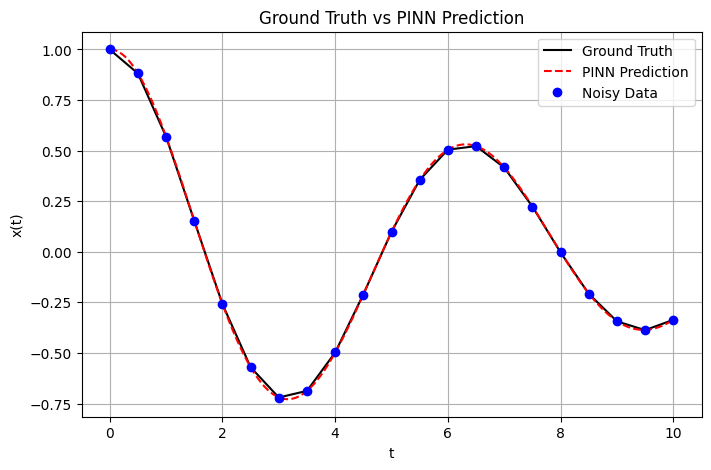

In [ ]:
import torch.nn as nn
from collections import OrderedDict

t_plot = np.linspace(0, 10, 400).reshape(-1, 1)
t_plot_tensor = torch.tensor(t_plot, dtype=torch.float32, device=device)

layers = [1, 64, 64, 1]

pinn = PhysicsInformedNN(
    t = t_train.astype(np.float32),
    t_colloc = t_colloc.astype(np.float32),
    u_data = y_train.astype(np.float32),
    layers=layers,
    lb=0,
    ub=10
)

pinn.train(adam_epochs=5000, bfgs_epochs=0, polish_adam_epochs=0)

with torch.no_grad():
    x_pinn = pinn.net_u(t_plot_tensor).cpu().numpy().reshape(-1)

plt.figure(figsize=(8,5))

plt.plot(t, x, 'k-', label='Ground Truth')

plt.plot(t_plot, x_pinn, 'r--', label='PINN Prediction')

plt.plot(t_train, y_train[:,0], 'bo', label='Noisy Data')

plt.xlabel('t')
plt.ylabel('x(t)')
plt.title('Ground Truth vs PINN Prediction')
plt.legend()
plt.grid(True)
plt.show()
